<a href="https://colab.research.google.com/github/pavlenkosasha/MillionaireAPI/blob/main/Uber_Pickups_in_New_York_City_PAVLENKO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

*Что мы подключили
pandas — работа с таблицами и CSV;
numpy — работа с числами и массивами;
matplotlib — построение графиков;*текст курсивом*
seaborn — удобная визуализация данных поверх Matplotlib.*

**Загружаем CSV**

In [28]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


**Завантажуємо дані за перший тиждень але тшльки 1000 пошздок,(для навчального проеку)**

переглядаємо файли в архіві

In [44]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    print(zip_ref.namelist())

['Uber-Jan-Feb-FOIL.csv', 'other-American_B01362.csv', 'other-Carmel_B00256.csv', 'other-Dial7_B00887.csv', 'other-Diplo_B01196.csv', 'other-FHV-services_jan-aug-2015.csv', 'other-Federal_02216.csv', 'other-Firstclass_B01536.csv', 'other-Highclass_B01717.csv', 'other-Lyft_B02510.csv', 'other-Prestige_B01338.csv', 'other-Skyline_B00111.csv', 'uber-raw-data-apr14.csv', 'uber-raw-data-aug14.csv', 'uber-raw-data-janjune-15.csv', 'uber-raw-data-jul14.csv', 'uber-raw-data-jun14.csv', 'uber-raw-data-may14.csv', 'uber-raw-data-sep14.csv']


вибираємо 1000 поїздок за перший тиждень

In [48]:
import zipfile
import pandas as pd

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    with zip_ref.open("uber-raw-data-apr14.csv") as file:
        all_data = pd.read_csv(file)

all_data["Date/Time"] = pd.to_datetime(all_data["Date/Time"])

week_data = all_data[
    (all_data["Date/Time"] >= "2014-04-01") &
    (all_data["Date/Time"] < "2014-04-08")
]

df = week_data.sample(n=1000, random_state=42)

print("Кількість поїздок:", len(df))
print("Період:", df["Date/Time"].min(), "-", df["Date/Time"].max())

Кількість поїздок: 1000
Період: 2014-04-01 00:07:00 - 2014-04-07 23:23:00


переглядаємо дані




In [49]:
df.head()

,Date/Time,Lat,Lon,Base
44529,2014-04-03 07:55:00,40.7469,-73.9817,B02598
68563,2014-04-07 17:00:00,40.7732,-73.9539,B02598
228250,2014-04-03 18:06:00,40.7559,-73.9768,B02617
373592,2014-04-06 15:04:00,40.7418,-73.9980,B02682
47358,2014-04-03 18:53:00,40.7207,-73.9996,B02598


інформація про таблицю

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 44529 to 59298
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date/Time  1000 non-null   datetime64[ns]
 1   Lat        1000 non-null   float64       
 2   Lon        1000 non-null   float64       
 3   Base       1000 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 39.1+ KB


статистика
df.describe()

Це покаже статистику числових колонок:

count — кількість;
mean — середнє;
std — стандартне відхилення;
min — мінімум;
25% — перший квартиль;
50% — медіана;
75% — третій квартиль;
max — максимум.

In [51]:
df.describe()

,Date/Time,Lat,Lon
count,1000,1000.00000,1000.000000
mean,2014-04-04 17:20:25.500000,40.74274,-73.978098
min,2014-04-01 00:07:00,40.49360,-74.443700
25%,2014-04-03 07:05:15,40.72475,-73.996425
50%,2014-04-04 18:25:00,40.74445,-73.983400
75%,2014-04-06 00:10:45,40.76290,-73.969075
max,2014-04-07 23:23:00,40.89420,-73.593300
std,NaN,0.03373,0.044822


пропущені значення

In [52]:
df.isnull().sum()

,0
Date/Time,0
Lat,0
Lon,0
Base,0


кількість дублікатів

In [53]:
df.duplicated().sum()

np.int64(0)

показуємо дублікати

In [54]:
df[df.duplicated()]

,Date/Time,Lat,Lon,Base


кількість унікальних значень

In [55]:
df.nunique()

,0
Date/Time,924
Lat,642
Lon,567
Base,5


які саме значення Base

In [56]:
df["Base"].unique()

array(['B02598', 'B02617', 'B02682', 'B02512', 'B02764'], dtype=object)

створюємо годину

In [57]:
df["Hour"] = df["Date/Time"].dt.hour

створюємо день місяця

In [58]:
df["Day"] = df["Date/Time"].dt.day

створюємо день тижня

In [59]:
df["DayOfWeek"] = df["Date/Time"].dt.day_name()

перевіряємо результат

In [60]:
df.head()

,Date/Time,Lat,Lon,Base,Hour,Day,DayOfWeek
44529,2014-04-03 07:55:00,40.7469,-73.9817,B02598,7,3,Thursday
68563,2014-04-07 17:00:00,40.7732,-73.9539,B02598,17,7,Monday
228250,2014-04-03 18:06:00,40.7559,-73.9768,B02617,18,3,Thursday
373592,2014-04-06 15:04:00,40.7418,-73.9980,B02682,15,6,Sunday
47358,2014-04-03 18:53:00,40.7207,-73.9996,B02598,18,3,Thursday


перевіряємо розподіл за днями тижня

In [61]:
df["DayOfWeek"].value_counts()

,count
DayOfWeek,
Friday,200
Saturday,168
Monday,149
Thursday,148
Wednesday,115
Tuesday,114
Sunday,106


графік за годинами

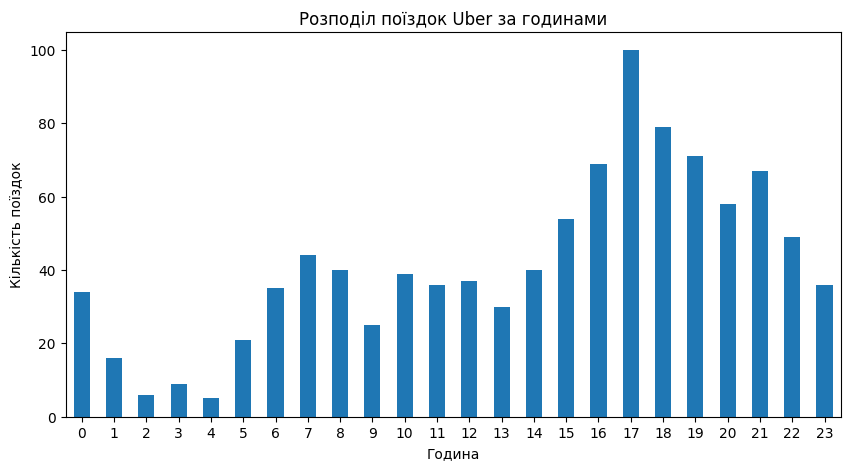

In [62]:
df["Hour"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Розподіл поїздок Uber за годинами")
plt.xlabel("Година")
plt.ylabel("Кількість поїздок")
plt.xticks(rotation=0)
plt.show()

графік за днями тижня

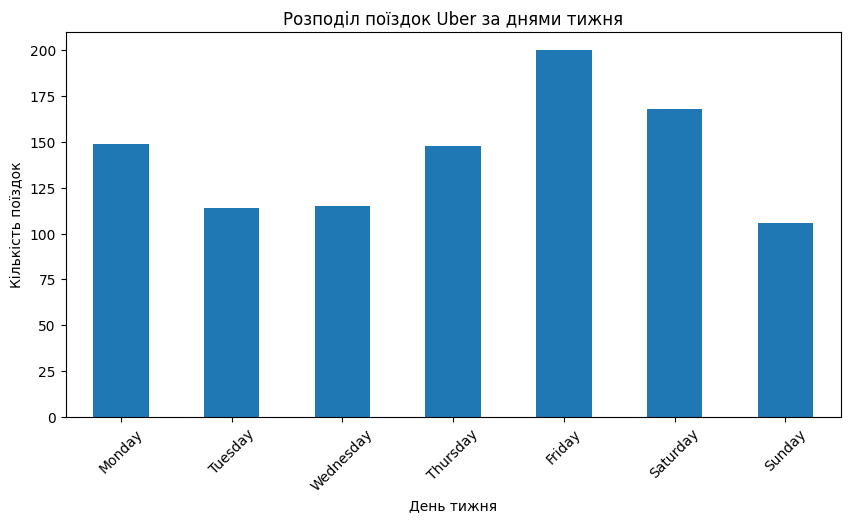

In [63]:
df["DayOfWeek"].value_counts().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Розподіл поїздок Uber за днями тижня")
plt.xlabel("День тижня")
plt.ylabel("Кількість поїздок")
plt.xticks(rotation=45)
plt.show()

**виконано:

✅ Завантаження даних

✅ Вибір 1000 поїздок

✅ Вибірка за цілий тиждень

✅ Перевірка структури

✅ Статистика

✅ Перевірка пропусків

✅ Перевірка дублікатів

✅ Перевірка унікальних значень

✅ Створення Hour

✅ Створення Day

✅ Створення DayOfWeek

✅ Аналіз за годинами

✅ Аналіз за днями тижня**